# Лабораторна 1. Основні бібліотеки. Лінійні моделі навчання.

В цій лабораторній роботі студенти:
- ознайомлюються з сервісом Colab;
- ознайомлюються з базовими бібліотеками для машинного навчання;
- тренують неглибокі лінійні моделі машинного навчання на базі простих регресій: лінійна, логістична, поліноміальна.

## 0. Налаштування середовища

### 0.0. Імпортуємо залежності

In [1]:
import sys
import os
import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt

### 0.1. Перевіряємо чи ми точно в Colab

In [2]:
IN_COLAB = "google.colab" in sys.modules
print("Running in Colab:", IN_COLAB)

assert IN_COLAB, f"Ця лаба має вокинуватися в Google Colab (https://colab.research.google.com/)"

Running in Colab: True


### 0.2. Фіксуємо всі джерела випадковості.
На GPU повна детермінованість трохи сповільнює тренування
(`cudnn.deterministic = True` вимикає частину швидких алгоритмів) —
тут це не критично, адже дані й модель дрібні.

In [3]:
SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

**Вправа 1.** Скористайся вбудованим модулем `random`. Спробуй `random.randint(1, 100)` і `random.shuffle()` на списку — випадковість буває не лише в числі, а й у перестановці. Згенеруй обома способами двічі ДО виклику `set_seed()` — переконайся, що результати різні. Потім ще двічі **ПІСЛЯ** з викликом set_seed() після кожної генерації і потім ще двічі **без проміжного виклику** `set_seed()`.

Після клітинки з кодом створи клітинку з маркдауном і поясни що відбувається після `set_seed()` і як це проявляється в результатах виконання коду.

In [4]:
numbers = list(range(10))  # список для shuffle

# 1. Двічі ДО set_seed()
print("--- ДО set_seed() ---")
print("Випадкове число 1:", random.randint(1, 100))
random.shuffle(numbers)
print("Перемішаний список 1:", numbers)

print("Випадкове число 2:", random.randint(1, 100))
random.shuffle(numbers)
print("Перемішаний список 2:", numbers)

# 2. Двічі ПІСЛЯ set_seed() (з викликом перед кожним)
print("\n--- ПІСЛЯ set_seed() (з викликом перед кожним) ---")
set_seed()
print("Випадкове число 1:", random.randint(1, 100))
set_seed()
print("Випадкове число 2:", random.randint(1, 100))

# 3. Двічі БЕЗ проміжних викликів set_seed()
print("\n--- БЕЗ проміжного set_seed() ---")
print("Випадкове число 1:", random.randint(1, 100))
print("Випадкове число 2:", random.randint(1, 100))


--- ДО set_seed() ---
Випадкове число 1: 29
Перемішаний список 1: [2, 6, 8, 3, 1, 9, 4, 5, 0, 7]
Випадкове число 2: 88
Перемішаний список 2: [9, 2, 5, 6, 4, 8, 1, 7, 3, 0]

--- ПІСЛЯ set_seed() (з викликом перед кожним) ---
Випадкове число 1: 82
Випадкове число 2: 82

--- БЕЗ проміжного set_seed() ---
Випадкове число 1: 15
Випадкове число 2: 4


Пояснення:

Функція set_seed() фіксує початковий стан (seed) генератора псевдовипадкових чисел.

1. До фіксації генератор щоразу повертає відмінні значення та перестановки.

2. Якщо викликати set_seed() перед кожною генерацією, генератор кожного разу скидається до початкового стану, тому значення стають ідентичними.

3. Якщо генерувати значення без проміжного виклику set_seed(), послідовність рухається далі, але лишається відтворюваною при перезапуску з тим самим seed.

### 0.3. Використовуємо лише CPU (в цій лабі)
На Colab зазвичай є безкоштовний GPU (T4), але для лінійної регресії
на кількасот точок CPU часто не повільніший — виграш GPU з'їдає пересилання
даних на пристрій і назад щоепохи. Тому нижче свідомо тренуємось на CPU.

In [5]:
device_available = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

print("Доступний пристрій :", device_available)
print("Використовуємо     :", device)
if device_available.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

assert device.type == "cpu", f"Ця лаба має виконуватися на CPU, а не на GPU ({device})"

Доступний пристрій : cpu
Використовуємо     : cpu


**Вправа 2.** Встанови CPU рантайм. Запусти комірку вище і зроби скріншот виводу. Потім у Colab зміни рантайм на GPU, перезапусти всі комірки від початку. Знову зроби скріншот тієї самої комірки. Збережи обидва скріншоти — пізніше завантажиш їх на GitHub разом зі здачею лаби.

### 0.4. Монтуємо Google Drive

Сесія Colab обмежена в часі й може скинутись — усе в `/content` зникає разом
з нею. Монтуємо Drive, щоб чекпоінт моделі й логи TensorBoard пережили
перезапуск.

In [6]:
from google.colab import drive
drive.mount("/content/drive")
ARTIFACT_DIR = "/content/drive/MyDrive/ai_systems/lab1"


os.makedirs(ARTIFACT_DIR, exist_ok=True)
RUNS_DIR = os.path.join(ARTIFACT_DIR, "runs")
os.makedirs(RUNS_DIR, exist_ok=True)
print("Артефакти зберігаються в:", ARTIFACT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Артефакти зберігаються в: /content/drive/MyDrive/ai_systems/lab1


---
## 1. Ознайомлення з бібліотеками

Кілька дуже простих вправ на NumPy, pandas, PyTorch і Matplotlib — щоб мати
спільну базу перед тим, як усі чотири підуть у хід одночасно.

### 1.1. NumPy

Документація: https://numpy.org/doc/stable/

**Вправа 3.** Створи масив форми 3×4, заповнений нулями (`np.zeros`), і ще один такої самої форми, заповнений числом 7 (`np.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [7]:
zeros_arr = np.zeros((3, 4))
sevens_arr = np.full((3, 4), 7)

print("Масив нулів:\n", zeros_arr, "\nShape:", zeros_arr.shape, "Dtype:", zeros_arr.dtype)
print("\nМасив сімок:\n", sevens_arr, "\nShape:", sevens_arr.shape, "Dtype:", sevens_arr.dtype)

Масив нулів:
 [[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] 
Shape: (3, 4) Dtype: float64

Масив сімок:
 [[7 7 7 7]
 [7 7 7 7]
 [7 7 7 7]] 
Shape: (3, 4) Dtype: int64


**Вправа 4.** Створи масив від 0 до 20 із кроком 2 через `np.arange`, і масив із 5 рівномірно розподілених точок від 0 до 1 через `np.linspace`. Виведи обидва.

In [8]:
arange_arr = np.arange(0, 20, 2)
linspace_arr = np.linspace(0, 1, 5)

print("arange:", arange_arr)
print("linspace:", linspace_arr)


arange: [ 0  2  4  6  8 10 12 14 16 18]
linspace: [0.   0.25 0.5  0.75 1.  ]


**Вправа 5.** Створи одиничну матрицю 4×4 (`np.eye`) і випадковий масив цілих чисел форми 3×3 у діапазоні [0, 10) (`np.random.randint`). Виведи `.ndim` обох масивів.

In [9]:
identity = np.eye(4)
random_ints = np.random.randint(0, 10, size=(3, 3))

print("Одинична матриця:\n", identity, "\nВимірність (.ndim):", identity.ndim)
print("\nВипадкові числа:\n", random_ints, "\nВимірність (.ndim):", random_ints.ndim)


Одинична матриця:
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]] 
Вимірність (.ndim): 2

Випадкові числа:
 [[6 3 7]
 [4 6 9]
 [2 6 7]] 
Вимірність (.ndim): 2


**Вправа 6.** Маєш масив оцінок студентів. Порахуй середнє, стандартне відхилення і z-normalized версію масиву — без циклів.

In [10]:
scores = np.array([78, 85, 92, 67, 90, 74, 88, 95, 60, 82])

mean = scores.mean()
std = scores.std()
z_scores = (scores - mean) / std

print("Середнє:", mean, " Std:", std)
print("Z-scores:", z_scores)


Середнє: 81.1  Std: 10.76522178127325
Z-scores: [-0.28796434  0.36227772  1.01251978 -1.30977329  0.82673633 -0.65953123
  0.64095289  1.29119495 -1.96001536  0.08360255]


**Вправа 7.** Маєш 1D масив із 12 чисел. Перетвори його на матрицю 3×4 і порахуй суму кожного рядка та кожного стовпця.

In [11]:
arr = np.arange(1, 13)

matrix = arr.reshape(3, 4)
row_sums = matrix.sum(axis=1)
col_sums = matrix.sum(axis=0)

print("Матриця 3x4:\n", matrix)
print("Сума по рядках:  ", row_sums)
print("Сума по стовпцях:", col_sums)

Матриця 3x4:
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
Сума по рядках:   [10 26 42]
Сума по стовпцях: [15 18 21 24]


### 1.2. pandas

Документація: https://pandas.pydata.org/docs/

**Вправа 8.** Створи таблицю студентів з оцінками. Виведи тільки тих, хто набрав більше 80 балів, відсортованих за спаданням оцінки.

In [12]:
# Створюємо датафрейм із даними студентів
data = {
    "name": ["Олександр", "Дарина", "Іван", "Наталія", "Артем"],
    "score": [91, 96, 79, 64, 83]
}
df = pd.DataFrame(data)

# Фільтруємо score > 80 і сортуємо за спаданням
top = df[df["score"] > 80].sort_values(by="score", ascending=False)
print(top)


        name  score
1     Дарина     96
0  Олександр     91
4      Артем     83


**Вправа 9.** Додай колонку `grade`: `A` якщо `score >= 90`, `B` якщо `score >= 75`, інакше `C`.

In [13]:
# Функція для визначення категорії оцінки
def get_grade(score):
    if score >= 90:
        return "A"
    elif score >= 75:
        return "B"
    else:
        return "C"

df["grade"] = df["score"].apply(get_grade)
print(df)


        name  score grade
0  Олександр     91     A
1     Дарина     96     A
2       Іван     79     B
3    Наталія     64     C
4      Артем     83     B


### 1.3. PyTorch

Документація: https://pytorch.org/docs/stable/index.html

**Вправа 10.** Створи тензор форми 2×3, заповнений нулями (`torch.zeros`), і ще один такої самої форми, заповнений числом 7 (`torch.full`). Виведи форму (`.shape`) і тип даних (`.dtype`) обох.

In [14]:
zeros_t = torch.zeros((2, 3))
sevens_t = torch.full((2, 3), 7)

print("Тензор нулів:\n", zeros_t, "\nShape:", zeros_t.shape, "Dtype:", zeros_t.dtype)
print("\nТензор сімок:\n", sevens_t, "\nShape:", sevens_t.shape, "Dtype:", sevens_t.dtype)


Тензор нулів:
 tensor([[0., 0., 0.],
        [0., 0., 0.]]) 
Shape: torch.Size([2, 3]) Dtype: torch.float32

Тензор сімок:
 tensor([[7, 7, 7],
        [7, 7, 7]]) 
Shape: torch.Size([2, 3]) Dtype: torch.int64


**Вправа 11.** Створи тензор від 0 до 20 із кроком 2 через `torch.arange`, і тензор із 5 рівномірно розподілених точок від 0 до 1 через `torch.linspace`.

In [15]:
arange_t = torch.arange(0, 20, 2)
linspace_t = torch.linspace(0, 1, 5)

print("arange_t:", arange_t)
print("linspace_t:", linspace_t)


arange_t: tensor([ 0,  2,  4,  6,  8, 10, 12, 14, 16, 18])
linspace_t: tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])


**Вправа 12.** Створи тензор напряму зі списку — `torch.tensor([[1, 2], [3, 4]])` — і випадковий тензор форми 3×3 через `torch.rand`. Виведи `.shape`, `.dtype` і `.ndim` обох.

In [16]:
from_list = torch.tensor([[1, 2], [3, 4]])
random_t = torch.rand(3, 3)

print("Зі списку:\n", from_list, "\nShape:", from_list.shape, "Dtype:", from_list.dtype, "Ndim:", from_list.ndim)
print("\nВипадковий:\n", random_t, "\nShape:", random_t.shape, "Dtype:", random_t.dtype, "Ndim:", random_t.ndim)

Зі списку:
 tensor([[1, 2],
        [3, 4]]) 
Shape: torch.Size([2, 2]) Dtype: torch.int64 Ndim: 2

Випадковий:
 tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009],
        [0.2566, 0.7936, 0.9408]]) 
Shape: torch.Size([3, 3]) Dtype: torch.float32 Ndim: 2


**Вправа 13.** Створи тензор `x = 5.0` з `requires_grad=True`, порахуй `y = x**2` і перевір автоматичний градієнт проти аналітичного ($dy/dx = 2x$).

In [17]:
n = 5.0
x = torch.tensor(n, requires_grad=True)
y = x ** 2
y.backward()  # Обчислює dy/dx = 2*x

print("Автоматичний градієнт PyTorch:", x.grad.item())
print("Аналітичний градієнт (2 * n):", 2 * n)


Автоматичний градієнт PyTorch: 10.0
Аналітичний градієнт (2 * n): 10.0


**Вправа 14.** Знайди $x$, який мінімізує $(x-3)^2 + 5$ — не аналітично, а градієнтним спуском: `x` як параметр з `requires_grad=True`, без жодної моделі.

In [18]:
x = torch.tensor(0.0, requires_grad=True)
lr = 0.1

for step in range(20):
    loss = (x - 3) ** 2 + 5
    loss.backward()
    with torch.no_grad():
        x -= lr * x.grad
    x.grad.zero_()

print(f"Оптимальне значення x = {x.item():.4f}  (теоретичний мінімум у x=3)")


Оптимальне значення x = 2.9654  (теоретичний мінімум у x=3)


### 1.4. Matplotlib

Документація: https://matplotlib.org/stable/index.html

**Вправа 15.** Побудуй графік функції $y = \sin(x)$ на проміжку $[0, 2\pi]$.

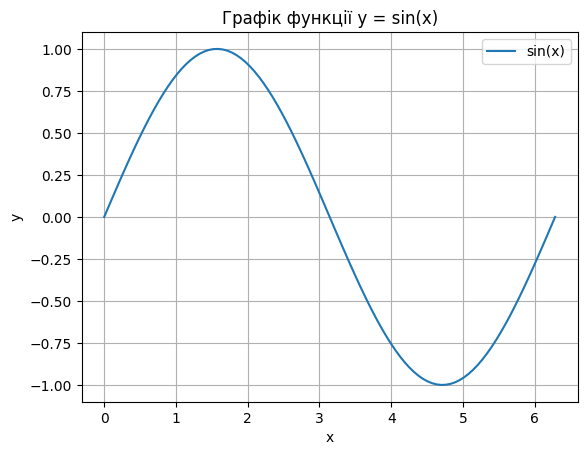

In [19]:
xs = np.linspace(0, 2 * np.pi, 100)
plt.plot(xs, np.sin(xs), label="sin(x)")
plt.title("Графік функції y = sin(x)")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

**Вправа 16.** На одному графіку познач дві групи точок різними кольорами і додай легенду.

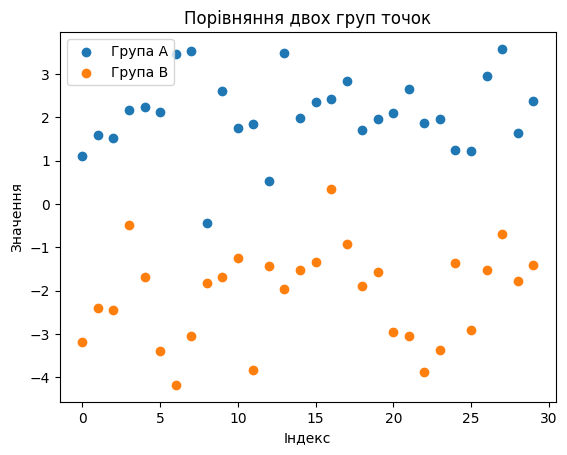

In [20]:
group_a = np.random.randn(30) + 2
group_b = np.random.randn(30) - 2

plt.scatter(range(30), group_a, color="C0", label="Група A")
plt.scatter(range(30), group_b, color="C1", label="Група B")
plt.title("Порівняння двох груп точок")
plt.xlabel("Індекс")
plt.ylabel("Значення")
plt.legend()
plt.show()

---
## Завдання 1. Лінійна регресія

Тренуємо базовий пайплайн на простій лінійній регресії з одним параметром.

$$y = w \cdot x + b + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, 1)$$

In [21]:
TASK1_TRUE_W = 2.0
TASK1_TRUE_B = 1.0
TASK1_N = 300

x1 = torch.empty(TASK1_N, 1).uniform_(-5, 5)
noise = 1.0 * torch.randn(TASK1_N, 1)
y1 = TASK1_TRUE_W * x1 + TASK1_TRUE_B + noise

**Вправа 17.** Перш ніж будувати модель — подивись на самі дані.

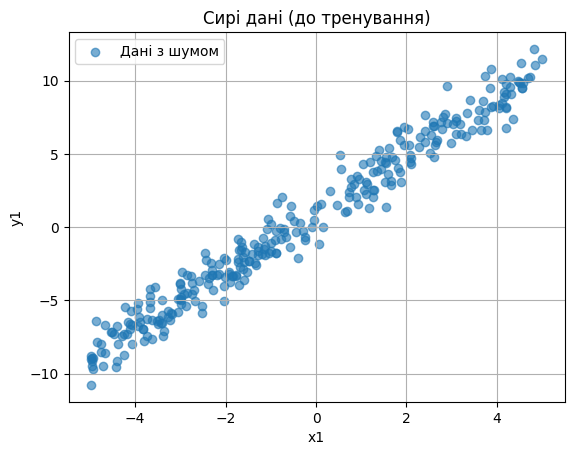

In [22]:
plt.scatter(x1.numpy(), y1.numpy(), alpha=0.6, label="Дані з шумом")
plt.xlabel("x1")
plt.ylabel("y1")
plt.title("Сирі дані (до тренування)")
plt.grid(True)
plt.legend()
plt.show()


**Вправа 18.** Розбий дані на train/val/test (70/15/15). Перемішай дані перед зрізом, інакше спліт вийде не випадковим.

In [23]:
# Перемішуємо індекси випадковим чином
perm = torch.randperm(TASK1_N)
x1_shuffled = x1[perm]
y1_shuffled = y1[perm]

# Обчислюємо розміри вибірок
train_size = int(0.70 * TASK1_N)
val_size = int(0.15 * TASK1_N)

# Робимо зрізи
x_train1 = x1_shuffled[:train_size]
y_train1 = y1_shuffled[:train_size]

x_val1 = x1_shuffled[train_size:train_size + val_size]
y_val1 = y1_shuffled[train_size:train_size + val_size]

x_test1 = x1_shuffled[train_size + val_size:]
y_test1 = y1_shuffled[train_size + val_size:]

print(f"train/val/test: {len(x_train1)}/{len(x_val1)}/{len(x_test1)}")


train/val/test: 210/45/45


**Вправа 19.** Нижче — готовий цикл навчання, кожен крок підписаний окремо. Просто запусти обидві комірки й подивись, як модель наближається до `true` за 100 епох (знімки кожні 30 епох).

In [24]:
task1_model = torch.nn.Linear(in_features=1, out_features=1)
optimizer = torch.optim.SGD(task1_model.parameters(), lr=0.05)
loss_fn = torch.nn.MSELoss()

x_line = torch.linspace(-5, 5, 100).unsqueeze(1)  # сітка для візуалізації лінії
snapshots = []  # (epoch, w, b, y_line_pred) кожні 30 епох

for epoch in range(100):
    # обнулити градієнти з попереднього кроку
    optimizer.zero_grad()
    # forward -- прогноз моделі на поточних w, b
    y_pred = task1_model(x_train1)
    # loss -- наскільки прогноз відрізняється від y_train1
    loss = loss_fn(y_pred, y_train1)
    # backward -- градієнти loss за w і b
    loss.backward()
    # крок оптимізатора -- оновити w і b
    optimizer.step()

    if epoch % 30 == 0 or epoch == 99:
        with torch.no_grad():
            y_line_pred = task1_model(x_line)
        snapshots.append((epoch, task1_model.weight.item(), task1_model.bias.item(), y_line_pred))
        print(f"epoch {epoch:4d}  loss={loss.item():.6f}  "
              f"w={task1_model.weight.item():.4f} (true {TASK1_TRUE_W})  "
              f"b={task1_model.bias.item():.4f} (true {TASK1_TRUE_B})")


epoch    0  loss=10.796704  w=1.7971 (true 2.0)  b=-0.2009 (true 1.0)
epoch   30  loss=1.030498  w=1.9806 (true 2.0)  b=1.0221 (true 1.0)
epoch   60  loss=1.026565  w=1.9829 (true 2.0)  b=1.0764 (true 1.0)
epoch   90  loss=1.026557  w=1.9830 (true 2.0)  b=1.0788 (true 1.0)
epoch   99  loss=1.026557  w=1.9830 (true 2.0)  b=1.0789 (true 1.0)


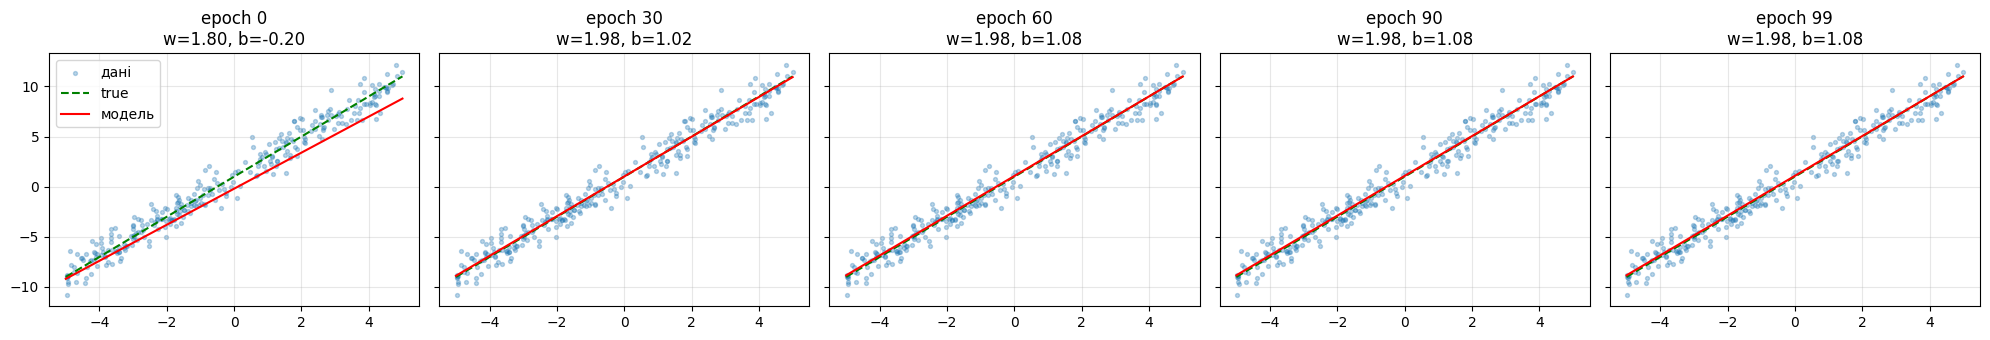

In [25]:
with torch.no_grad():
    y_line_true = TASK1_TRUE_W * x_line + TASK1_TRUE_B

fig, axes = plt.subplots(1, len(snapshots), figsize=(4 * len(snapshots), 3.5), sharey=True)
for ax, (epoch, w, b, y_line_pred) in zip(axes, snapshots):
    ax.scatter(x1.numpy(), y1.numpy(), s=8, alpha=0.3, label="дані")
    ax.plot(x_line.numpy(), y_line_true.numpy(), "g--", label="true")
    ax.plot(x_line.numpy(), y_line_pred.numpy(), "r-", label="модель")
    ax.set_title(f"epoch {epoch}\nw={w:.2f}, b={b:.2f}")
    ax.grid(alpha=0.3)
axes[0].legend()
plt.tight_layout()
plt.show()


**Вправа 20.** Придумай власний напів-реальний сценарій лінійної залежності
(наприклад: кількість з'їдених пачок чіпсів на тиждень → індекс маси тіла;
години сну → продуктивність; щось своє). У markdown-комірці перед кодом
опиши сценарій: яку залежність ти
закладаєш ($w$, $b$) і чому саме такі значення видались тобі правдоподібними.
Згенеруй дані з шумом, збережи їх у CSV файл (за зразком відповідної частини лекції)
і натренуй лінійну регресію за тим самим патерном — спліт, цикл навчання, перевірка на test.
Організуй код тренування у логічні перевикористовувані функції.

Сценарій залежності:
Досліджуємо вплив кількості годин танцювальних тренувань на тиждень (x) на фінальний бал за виступ (y).   

Формула залежності: y=w⋅x+b+ε
  
w=6.0 (кожна година тренувань на тиждень підвищує оцінку в середньому на 6 балів).   
b=20.0 (відчуття ритму та пластика оцінюються у 20 балів зі 100 навіть без підготовки).   
ε∼N(0,4) (випадковості: хвилювання, втома та інше).

In [26]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Генерація штучних даних (Танці)
torch.manual_seed(42)
N_SAMPLES = 200
TRUE_W = 6.0
TRUE_B = 20.0

dance_hours = torch.empty(N_SAMPLES, 1).uniform_(0, 12)  # від 0 до 12 годин тренувань
noise = 4.0 * torch.randn(N_SAMPLES, 1)
performance_score = TRUE_W * dance_hours + TRUE_B + noise

# 2. Збереження датасету у CSV файл
df_custom = pd.DataFrame({
    "dance_hours": dance_hours.squeeze().numpy(),
    "performance_score": performance_score.squeeze().numpy()
})
csv_path = os.path.join(ARTIFACT_DIR, "dataset.csv")
df_custom.to_csv(csv_path, index=False)
print(f"Датасет успішно збережено у: {csv_path}")

# 3. Перевикористовувані функції розділення та навчання
def split_data(x, y, train_ratio=0.7, val_ratio=0.15):
    perm = torch.randperm(len(x))
    x_sh, y_sh = x[perm], y[perm]
    train_end = int(train_ratio * len(x))
    val_end = train_end + int(val_ratio * len(x))
    return (x_sh[:train_end], y_sh[:train_end]), (x_sh[train_end:val_end], y_sh[train_end:val_end]), (x_sh[val_end:], y_sh[val_end:])

def train_linear_model(x_train, y_train, epochs=200, lr=0.01):
    model = nn.Linear(1, 1)
    optimizer = optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for epoch in range(epochs):
        optimizer.zero_grad()
        y_pred = model(x_train)
        loss = loss_fn(y_pred, y_train)
        loss.backward()
        optimizer.step()

    return model, loss_fn

# 4. Розділення даних, навчання та тестування
(x_tr, y_tr), (x_va, y_va), (x_te, y_te) = split_data(dance_hours, performance_score)
my_model, loss_fn = train_linear_model(x_tr, y_tr)

with torch.no_grad():
    test_preds = my_model(x_te)
    test_loss = loss_fn(test_preds, y_te).item()

print(f"Оцінені параметри моделі: w = {my_model.weight.item():.2f}, b = {my_model.bias.item():.2f}")
print(f"Середньоквадратична помилка (MSE) на тесті: {test_loss:.4f}")

Датасет успішно збережено у: /content/drive/MyDrive/ai_systems/lab1/dataset.csv
Оцінені параметри моделі: w = 6.84, b = 14.03
Середньоквадратична помилка (MSE) на тесті: 13.5023


**Вправа 21.** Збережи натреновану модель на своєму гугл диску у файлі з назвою `model.pt`.
Збережений файл потрібно буде також здати разом з лабою.

In [27]:
model_path = os.path.join(ARTIFACT_DIR, "model.pt")
torch.save(my_model.state_dict(), model_path)
print(f"Модель успішно збережено у: {model_path}")

Модель успішно збережено у: /content/drive/MyDrive/ai_systems/lab1/model.pt


**Вправа 22.** Встанови [Gradio](https://gradio.app/)
```
!pip install -q gradio
import gradio as gr
```
Завантаж свою модель, збережену в попередній вправі і створи інтерактивну аппку.

In [28]:
!pip install -q gradio
import gradio as gr

# Завантажуємо збережені ваги моделі
loaded_model = nn.Linear(1, 1)
loaded_model.load_state_dict(torch.load(os.path.join(ARTIFACT_DIR, "model.pt")))
loaded_model.eval()

# Функція прогнозування з обмеженнями
def predict_performance(hours_input):
    hours_clamped = max(0.0, min(12.0, float(hours_input)))

    with torch.no_grad():
        x_tensor = torch.tensor([[hours_clamped]], dtype=torch.float32)
        prediction = loaded_model(x_tensor).item()

    score = max(0.0, min(100.0, prediction))
    return round(score, 1)

# Створюємо Gradio-інтерфейс зі слайдером
demo = gr.Interface(
    fn=predict_performance,
    inputs=gr.Slider(minimum=0, maximum=12, step=0.5, value=6, label="Кількість годин тренувань на тиждень (0 - 12)"),
    outputs=gr.Number(label="Прогнозований бал за виступ (0 - 100)"),
    title="Прогноз успішності танцюриста",
    description="Перетягуйте слайдер, щоб обрати кількість годин відпрацювання хореографії."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1be2f755bc2800239c.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---
### Як здавати лабу
У [форму](https://forms.gle/5qxRYshxKknBXDCz8) здати посилання на **публічний** репозиторій, який містить:
1. **Цей ноутбук з усіма виконаними вправами**. Ноутбук має запускатися зверху до низу (Run All) в будь-якому середовищі без помилок.
2. **Додаткові скріншоти** по ходу виконання лаби (якими Ви доводите, що справді виконували цбю лабу).
3. Створений по ходу виконання лаби **csv файл** з даними і **pt файл** з моделлю.
4. Структура файлів на репозиторії, **точно дотримуйтесь, інакше не зарахується лаба**:
```
    /lab1/linear_models_lab.ipynb
    /lab1/screenshots/*
    /lab1/dataset.csv
    /lab1/model.pt
```